# Objective

## What are we trying to do?

The objective of this analysis is to identify groups of Indian States and Union Territories that exhibit similar patterns of women's digital inclusion. Instead of examining internet access, mobile ownership, gender parity, rural–urban disparity, and financial inclusion independently, clustering allows the administrative units to be analyzed according to their overall digital-inclusion profile.

This is relevant because two regions may have similar levels of internet access but differ substantially in other dimensions. For example, one region may have high internet access and mobile ownership but a large rural–urban gap, while another may have slightly lower internet access but greater gender and geographic equity. Therefore, a multidimensional approach is needed to identify these differences.

The selected features represent different dimensions of women's digital inclusion:

<table border="1" cellpadding="8" cellspacing="0">
  <thead>
    <tr>
      <th>Variable</th>
      <th>What it represents</th>
      <th>Why it matters</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Women_Internet_pct_total</td>
      <td>Overall internet access among women</td>
      <td>Measures the extent to which women are actually connected</td>
    </tr>
    <tr>
      <td>gpi_internet</td>
      <td>Gender parity in internet access</td>
      <td>Measures whether women's access is comparable with men's access</td>
    </tr>
    <tr>
      <td>internet_to_mobile_conversion</td>
      <td>Conversion from mobile ownership to internet use</td>
      <td>Indicates whether access to mobile devices translates into actual internet participation</td>
    </tr>
    <tr>
      <td>women_bank_account_pct_total</td>
      <td>Women's financial inclusion</td>
      <td>Represents women's access to formal financial services and the foundation for digital financial participation</td>
    </tr>
    <tr>
      <td>Electricity_Access_total</td>
      <td>Basic infrastructure availability</td>
      <td>Represents the underlying infrastructure required to support digital connectivity and device usage</td>
    </tr>
  </tbody>
</table>

The important point is that these variables measure different dimensions of the same broader phenomenon. Internet access alone cannot determine whether digital inclusion is equitable or meaningful

## Why use clustering?

Clustering is used because the objective is not to predict an outcome, but to discover naturally occurring groups within the data.

The algorithm examines the similarity between administrative units across the five indicators and groups units with similar profiles.
For example, two states could both have high internet access, but if one has substantially lower female mobile ownership or greater rural–urban disparity, clustering can separate them into different groups.
Therefore, clustering converts a set of individual indicators into interpretable regional digital-inclusion profiles.

## Technique and Machine Learning Approach

A multivariate unsupervised learning approach will be used to identify groups of States and Union Territories with similar patterns of women's digital inclusion. The selected variables will first be standardized using StandardScaler. PCA will be used to assess the underlying structure of the indicators and visualize the data in reduced dimensions. K-Means clustering will then be applied to group administrative units based on their similarity across the selected indicators. The optimal number of clusters will be evaluated using the Elbow Method and Silhouette Score.

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_rbi = pd.read_csv("../dataset/clean/after_metrics_calculated/rbi.csv",  parse_dates=["Date"])
df_telecom_sub = pd.read_csv("../dataset/clean/after_metrics_calculated/telecom_sub.csv",  parse_dates=["date"])
df_nfhs = pd.read_csv("../dataset/clean/after_metrics_calculated/nfhs.csv")

## Step 1 - Feature Selection

In [14]:
features = ['Women_Internet_pct_total', 'gpi_internet', 'internet_to_mobile_conversion',
            'women_bank_account_pct_total', 'Electricity_Access_total']

In [16]:
df_features_to_use = df_nfhs[features]

## Step 2 - Check collinearity before you PCA blind

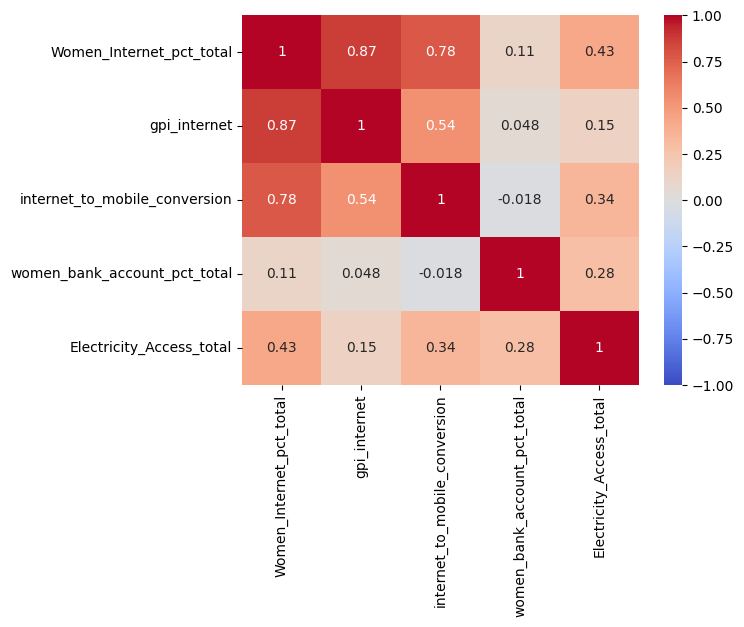

In [18]:
corr = df_features_to_use.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

## Step 3- Apply Standard Scaler and PCA

In [19]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features_to_use)

In [24]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[0.53291608 0.23505303 0.14535925 0.07863967 0.00803197]
[0.53291608 0.7679691  0.91332835 0.99196803 1.        ]


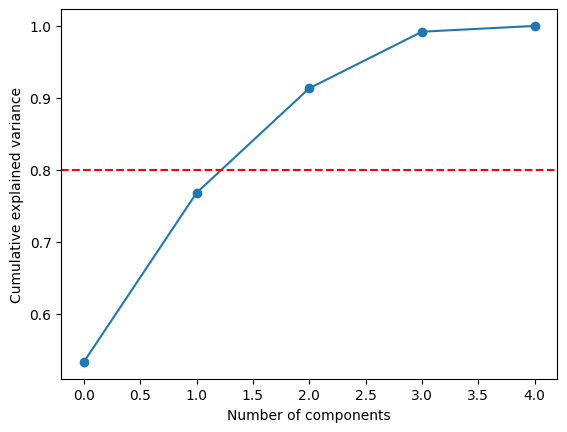

In [26]:
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.show()

In [22]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(len(features))]
)

loadings

,PC1,PC2,PC3,PC4,PC5
Women_Internet_pct_total,0.598999,-0.087561,-0.088764,-0.107578,0.783633
gpi_internet,0.512941,-0.246004,-0.429150,-0.458393,-0.531112
internet_to_mobile_conversion,0.512915,-0.154728,0.231542,0.762793,-0.278410
women_bank_account_pct_total,0.104715,0.780562,-0.562554,0.250599,-0.022144
Electricity_Access_total,0.322561,0.546440,0.661719,-0.365581,-0.160736


PCA showed that the first two principal components explained 76.80% of the total variance, providing a useful two-dimensional representation of the data for exploratory visualization. 

PC1 primarily represents the digital access and gender-equity dimension, while PC2 captures a financial and infrastructure dimension of women's digital inclusion. The remaining components were retained for consideration in the clustering analysis rather than being discarded solely based on the two-dimensional representation.

## Step 4 - Determine K

Inertia: [107.55884164925493, 83.52779614661344, 64.59974178657727, 53.60753555124683, 45.159824671768774]
Silhouette Scores: [np.float64(0.30687276323795315), np.float64(0.27397018101847326), np.float64(0.28403787005676673), np.float64(0.2577801134002345), np.float64(0.252699022333581)]


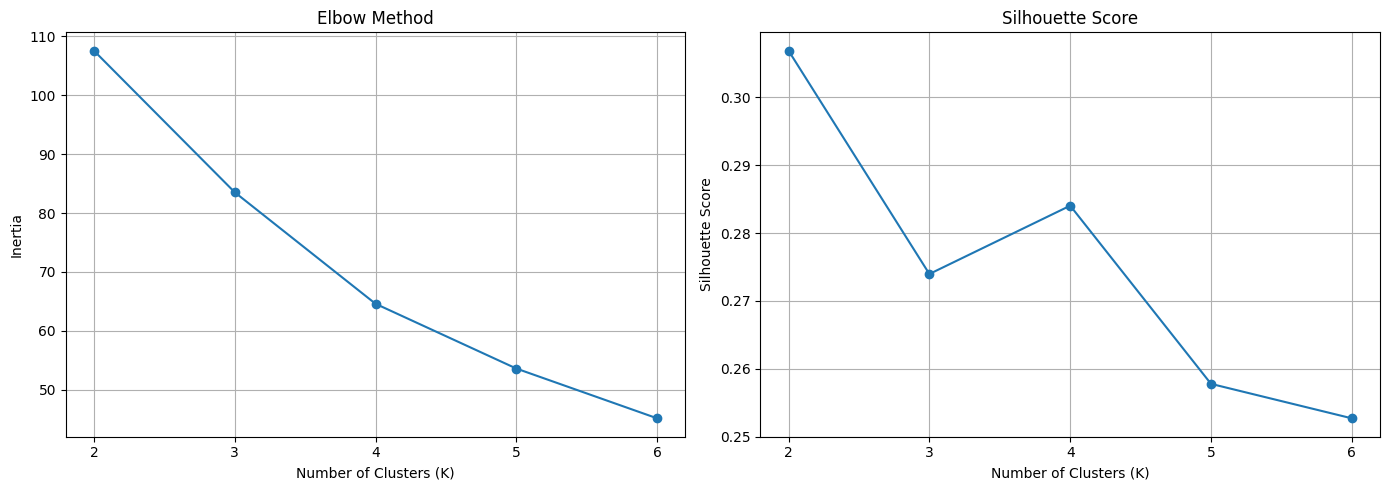

In [32]:
inertia = []
silhouette_scores = []

k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# Print results
print("Inertia:", inertia)
print("Silhouette Scores:", silhouette_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_values, inertia, marker='o')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_values))
axes[0].grid(True)

# Silhouette Score
axes[1].plot(k_values, silhouette_scores, marker='o')
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].set_xticks(list(k_values))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [33]:
for k in [2, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    print(f"\nK = {k}")
    print("Silhouette Score:", silhouette_score(X_scaled, labels))


K = 2
Silhouette Score: 0.30687276323795315

K = 4
Silhouette Score: 0.28403787005676673


The number of clusters was evaluated using both the Elbow Method and Silhouette Score. The Elbow Method indicated diminishing reductions in within-cluster variation around K=4, while the highest Silhouette Score was observed at K=2. Therefore, candidate solutions of K=2 and K=4 were further compared based on cluster profiles and interpretability before selecting the final clustering solution

## for k = 2

In [35]:
df_cluster = df_nfhs.copy()

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = df_cluster.groupby("Cluster")[features].mean()

cluster_profile

,Women_Internet_pct_total,gpi_internet,internet_to_mobile_conversion,women_bank_account_pct_total,Electricity_Access_total
Cluster,,,,,
0,58.78125,0.767152,77.497552,80.250000,99.2
1,31.30000,0.559206,56.423292,79.368421,97.1


## for k = 4

In [37]:
df_cluster_four = df_nfhs.copy()

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_cluster_four["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = df_cluster_four.groupby("Cluster")[features].mean()

cluster_profile

,Women_Internet_pct_total,gpi_internet,internet_to_mobile_conversion,women_bank_account_pct_total,Electricity_Access_total
Cluster,,,,,
0,35.560000,0.657773,59.967406,76.420000,92.920000
1,30.845455,0.540640,51.493746,84.109091,98.581818
2,62.663636,0.798923,82.378894,82.072727,99.554545
3,41.100000,0.609412,67.445915,72.737500,98.500000


K=2 provides the strongest overall cluster separation, while K=4 provides a more detailed segmentation of the different dimensions of women's digital inclusion.Before making the final choice, I should check cluster sizes. A K=4 solution is much harder to justify if one of the four clusters contains only a few States/UTs.

In [38]:
print("K = 2")
print(df_cluster["Cluster"].value_counts().sort_index())

print("\nK = 4")``
print(df_cluster_four["Cluster"].value_counts().sort_index())

K = 2
Cluster
0    16
1    19
Name: count, dtype: int64

K = 4
Cluster
0     5
1    11
2    11
3     8
Name: count, dtype: int64


## two additional validation metrics

In [41]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

for k in [2, 3, 4, 5, 6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    print(f"\nK = {k}")
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled, labels))
    print("Davies-Bouldin:", davies_bouldin_score(X_scaled, labels))


K = 2
Silhouette: 0.30687276323795315
Calinski-Harabasz: 20.691541406070943
Davies-Bouldin: 1.196399763812381

K = 3
Silhouette: 0.27397018101847326
Calinski-Harabasz: 17.521775135611833
Davies-Bouldin: 1.3048893470297305

K = 4
Silhouette: 0.28403787005676673
Calinski-Harabasz: 17.659554615161134
Davies-Bouldin: 1.0653036461433185

K = 5
Silhouette: 0.2577801134002345
Calinski-Harabasz: 16.9834981967283
Davies-Bouldin: 1.0340131748885897

K = 6
Silhouette: 0.252699022333581
Calinski-Harabasz: 16.67572942050232
Davies-Bouldin: 0.9664948607026459


Silhouette: K=2 is clearly highest at 0.3069. This indicates the two-cluster solution provides the strongest separation and cohesion among the tested K values.

Calinski-Harabasz: Again, K=2 is highest at 20.69. This supports the idea that K=2 has the strongest between-cluster separation relative to within-cluster dispersion.

Davies-Bouldin: K=6 has the lowest value, which is technically better. However, this metric keeps improving as K increases while the other two metrics deteriorate. 

## Final Conclusion of using k =2 as final clustering solution.

The evidence is
<ul>
<li>K=2 has the highest Silhouette Score.</li>
<li>K=2 has the highest Calinski-Harabasz Index.</li>
<li>K=2 has a reasonable Davies-Bouldin value, although not the minimum.</li>
<li>K=2 produces reasonably balanced clusters: 16 and 19 observations.</li>
<li>The Elbow plot showed diminishing returns around K=4, but it did not provide stronger evidence than the two other metrics for K=4.</li>
</ul>

The optimal number of clusters was evaluated using the Elbow Method, Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index. Although the Elbow Method indicated diminishing reductions in within-cluster variation around K=4, the K=2 solution achieved the highest Silhouette Score (0.307) and Calinski-Harabasz Index (20.69), indicating stronger cluster separation and cohesion. Therefore, K=2 was selected as the primary clustering solution. The K=4 solution was additionally examined as a sensitivity analysis to assess whether a more granular segmentation produced substantively distinct profiles

## Step 5 - States/UTs in each cluster

In [47]:
cluster_members = (
    df_cluster[["state_ut", "Cluster"]]
    .sort_values(["Cluster", "state_ut"])
)

print(cluster_members.to_string(index=False))

                              state_ut  Cluster
                     Arunachal Pradesh        0
                            Chandigarh        0
                                   Goa        0
                               Haryana        0
                      Himachal Pradesh        0
                                Kerala        0
                                Ladakh        0
                           Lakshadweep        0
                               Mizoram        0
                          NCT of Delhi        0
                              Nagaland        0
                            Puducherry        0
                                Punjab        0
                                Sikkim        0
                            Tamil Nadu        0
                           Uttarakhand        0
             Andaman & Nicobar Islands        1
                        Andhra Pradesh        1
                                 Assam        1
                                 Bihar  

## Step 6 - Create the cluster profile

In [49]:
cluster_profile = (
    df_cluster
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,Women_Internet_pct_total,gpi_internet,internet_to_mobile_conversion,women_bank_account_pct_total,Electricity_Access_total
Cluster,,,,,
0,58.78,0.77,77.50,80.25,99.2
1,31.30,0.56,56.42,79.37,97.1


## Step 6 - Calculate the difference between clusters

In [51]:
cluster_difference = (
    cluster_profile.loc[0] - cluster_profile.loc[1]
).round(2)

cluster_difference

Women_Internet_pct_total         27.48
gpi_internet                      0.21
internet_to_mobile_conversion    21.08
women_bank_account_pct_total      0.88
Electricity_Access_total          2.10
dtype: float64

## Step 7 — Compare the clusters visually

In [53]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df_nfhs.index
)

# Add cluster labels
X_scaled_df["Cluster"] = df_cluster["Cluster"].values

# Calculate standardized cluster means
cluster_profile_scaled = (
    X_scaled_df
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile_scaled

,Women_Internet_pct_total,gpi_internet,internet_to_mobile_conversion,women_bank_account_pct_total,Electricity_Access_total
Cluster,,,,,
0,0.93,0.80,0.73,0.07,0.49
1,-0.78,-0.68,-0.62,-0.06,-0.41


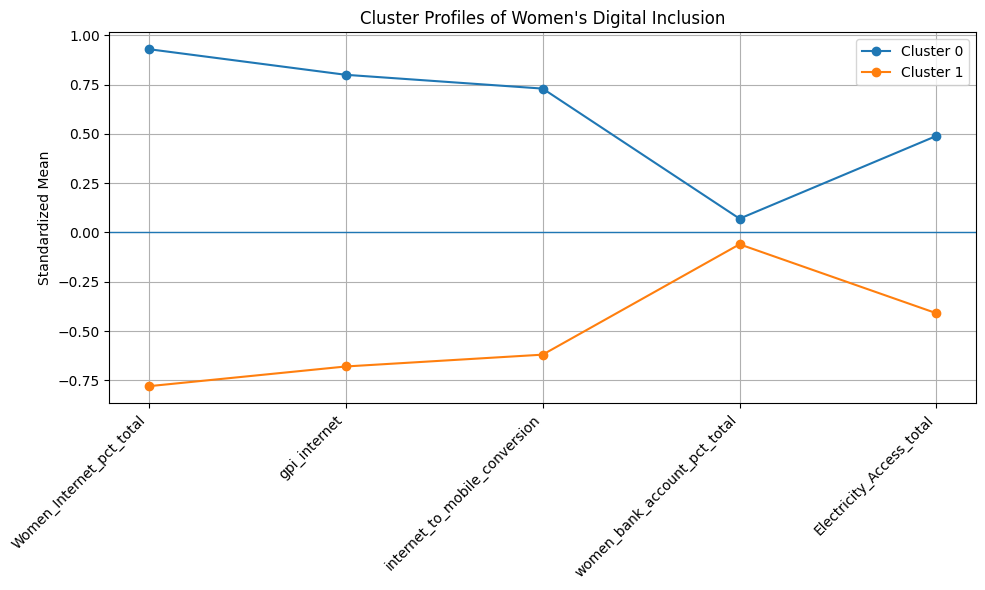

In [54]:
plt.figure(figsize=(10, 6))

for cluster in cluster_profile_scaled.index:
    plt.plot(
        features,
        cluster_profile_scaled.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standardized Mean")
plt.title("Cluster Profiles of Women's Digital Inclusion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The K-Means clustering identified two groups of States/UTs with distinct levels of women's digital inclusion. Cluster 0 showed above-average values across all five indicators, with particularly strong performance in women's internet access, gender parity in internet access, and internet-to-mobile conversion. Cluster 1 showed below-average values across these indicators. The largest separation between the clusters occurred in direct digital-access indicators, whereas women's bank-account ownership showed very little difference between the groups. This suggests that financial inclusion is relatively similar across the two clusters, while differences in women's actual digital connectivity are more pronounced.

In [56]:
final_clusters = df_cluster[
    ["state_ut", "Cluster"] + features
].sort_values("Cluster")

final_clusters

,state_ut,Cluster,Women_Internet_pct_total,gpi_internet,internet_to_mobile_conversion,women_bank_account_pct_total,Electricity_Access_total
2,Arunachal Pradesh,0,52.9,0.738827,69.240838,78.2,94.8
5,Chandigarh,0,75.2,0.818281,107.428571,87.1,99.9
10,Haryana,0,48.4,0.668508,96.031746,73.6,99.6
8,Goa,0,73.7,0.889023,80.811404,88.3,100.0
15,Kerala,0,61.1,0.802891,70.554273,78.5,99.6
11,Himachal Pradesh,0,49.7,0.731959,62.515723,83.1,99.5
17,Lakshadweep,0,56.4,0.702366,67.142857,66.9,99.8
30,Tamil Nadu,0,46.9,0.668091,62.868633,92.2,99.3
24,NCT of Delhi,0,63.8,0.748826,86.449864,72.5,99.9
26,Puducherry,0,61.9,0.767038,74.668275,92.6,99.9


Cluster 0 is characterized by higher women's digital connectivity, particularly internet access, gender parity, and internet-to-mobile conversion.

So Cluster 1 is characterized by lower women's digital connectivity, particularly lower internet access, gender parity, and internet-to-mobile conversion.

Women's financial inclusion and basic electricity access are relatively widespread across the States/UTs, but women's internet access, gender parity in internet access, and the conversion of mobile ownership into internet use show a substantially stronger divide.

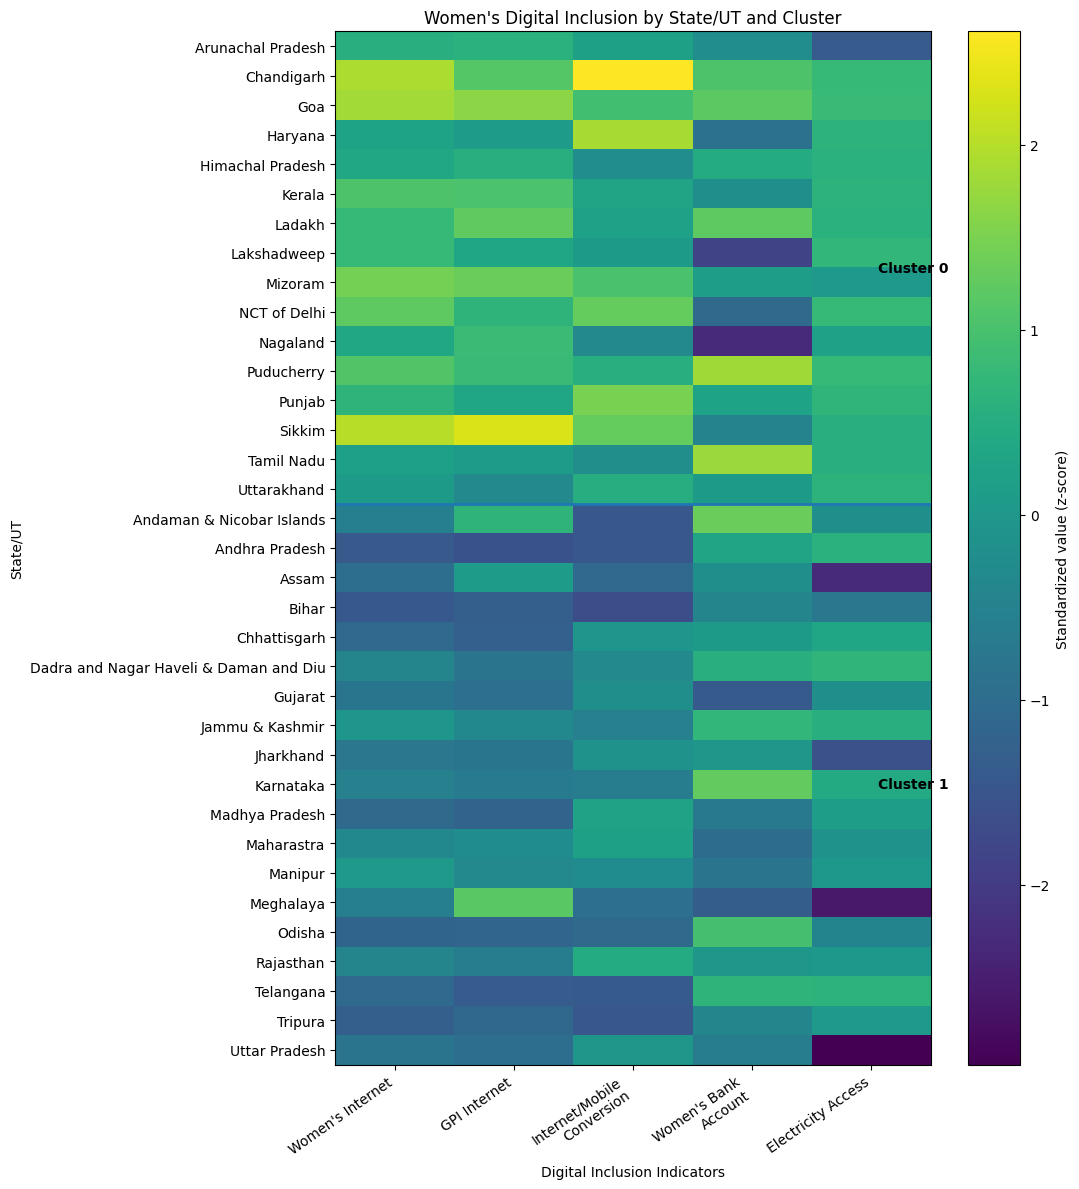

In [57]:
heatmap_data = df_cluster[["state_ut", "Cluster"] + features].copy()

# Sort States/UTs by cluster
heatmap_data = heatmap_data.sort_values(["Cluster", "state_ut"])

# Standardize the five indicators so they are comparable
heatmap_values = heatmap_data[features].copy()
heatmap_values = (heatmap_values - heatmap_values.mean()) / heatmap_values.std()

fig, ax = plt.subplots(figsize=(11, 12))

im = ax.imshow(heatmap_values.values, aspect="auto")

ax.set_xticks(range(len(features)))
ax.set_xticklabels([
    "Women's Internet",
    "GPI Internet",
    "Internet/Mobile\nConversion",
    "Women's Bank\nAccount",
    "Electricity Access"
], rotation=35, ha="right")

ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data["state_ut"])

ax.set_xlabel("Digital Inclusion Indicators")
ax.set_ylabel("State/UT")
ax.set_title("Women's Digital Inclusion by State/UT and Cluster")

# Add cluster separators
cluster_sizes = heatmap_data["Cluster"].value_counts().sort_index()
boundary = cluster_sizes.iloc[0] - 0.5
ax.axhline(boundary, linewidth=2)

# Add cluster labels on the right
ax.text(
    len(features) - 0.35,
    (cluster_sizes.iloc[0] - 1) / 2,
    "Cluster 0",
    ha="right",
    va="center",
    fontweight="bold"
)

ax.text(
    len(features) - 0.35,
    cluster_sizes.iloc[0] + (cluster_sizes.iloc[1] - 1) / 2,
    "Cluster 1",
    ha="right",
    va="center",
    fontweight="bold"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Standardized value (z-score)")

plt.tight_layout()
plt.show()

K-Means clustering identified two distinct groups among the 35 States and Union Territories based on women's digital inclusion indicators. Cluster 0, comprising 16 States/UTs, showed higher average women's internet access (58.78%), gender parity in internet access (0.767), and internet-to-mobile conversion (77.50%). Cluster 1, comprising 19 States/UTs, showed lower values for these indicators, with averages of 31.30%, 0.559, and 56.42%, respectively. In contrast, women's bank-account ownership differed by less than one percentage point between the clusters, while electricity access differed by approximately two percentage points. This indicates that the primary distinction between the clusters is associated with women's digital connectivity rather than differences in basic infrastructure or financial account ownership